In [3]:
import pandas as pd
import sqlite3

In [4]:
# Para crear una base de datos nueva abrimos una conexión con un nombre nuevo
connection = sqlite3.connect("birras.db")

# Obtenemos un cursor que utilizaremos para hacer las queries
# Lo necesita
crsr = connection.cursor()

In [9]:
#crsr.execute("DROP TABLE Cervezas")

In [ ]:
# He creado todas las tablas a mano. Cuando ya voy por la tercera empiezo a pensar que no sé si era la forma
# esperada de hacer el ejercicio. Habrá una forma más eficiente... pero teniendo en cuenta que los datos están
# escritos en un archivo me cuesta lo mismo copiar y pegarlos para crear la tabla que para hacer un bucle 
# que los lea

#Creamos la primera tabla
query = '''
 CREATE TABLE Cervezas (
     CodC varchar (255),
     Envase varchar(255),
     Capacidad float,
     Stock int
 );
 '''
crsr.execute(query)


In [14]:
#Metemos los valores
query = '''
 INSERT INTO Cervezas (CodC, Envase, Capacidad, Stock)
 VALUES 
    ("01", "Botella", 0.2, 3600),
    ("02", "Botella", 0.33, 1200),
    ("03", "Lata", 0.33, 2400),
    ("04", "Botella", 1, 288),
    ("05", "Barril", 60, 30);

'''
crsr.execute(query)


In [15]:
# Comprobamos
query = '''
 SELECT * FROM Cervezas
 '''
crsr.execute(query).fetchall()

[(1, 'Botella', 0.2, 3600),
 (2, 'Botella', 0.33, 1200),
 (3, 'Lata', 0.33, 2400),
 (4, 'Botella', 1.0, 288),
 (5, 'Barril', 60.0, 30)]

In [ ]:

# He tenido que borrar la tabla para crearla de nuevo con CodB como string para que me admita los ceros por 
#delante
#crsr.execute("DROP TABLE Bares")


In [ ]:

query = '''
 CREATE TABLE Bares (
     CodB varchar(255),
     Cif varchar(255),
     Nombre varchar(255),
     Localidad varchar(255)
 );
 '''
crsr.execute(query)



In [ ]:
#Lo mismo con el resto de tablas. Uso executemany
query = '''
 INSERT INTO Bares (CodB, Cif, Nombre, Localidad)
 VALUES 
    (?, ?, ?, ?);

'''
bares = [
    ("001","11111111X","Stop", "Villa Botijo"),
    ("002", "22222222Y","Las Vegas", "Villa Botijo"),
    ("003",  "-", "Club Social", "Las Ranas"),
    ("004", "33333333Z", "Otra Ronda", "La Esponja"
)
]
crsr.executemany (query, bares)

In [ ]:
#La había creado mal
#crsr.execute("DROP TABLE Empleados")

In [18]:
query = '''
    CREATE TABLE Empleados (
         CodE int, 
         Nombre varchar(255),
         Sueldo int
);         
'''
crsr.execute (query)

In [19]:
query = '''
 INSERT INTO Empleados (CodE, Nombre, Sueldo)
 VALUES 
    (?, ?, ?);

'''
empleados = [
    (1, "Prudencio Caminero", 120000),
    (2, "Vicente Merario", 110000),
    (3, "Valentin Siempre",100000)
]

crsr.executemany (query, empleados)

In [66]:
# Ojo a la fecha. Viene en formato mm-dd-aa
query = '''
    CREATE TABLE Reparto (
    CodE int,
    CodB varchar(255),
    CodC varchar(255),
    Fecha varchar (255), -- lo meto a mano en formato ISO yyyy-mm-dd
    Cantidad int
    );
'''
crsr.execute (query)

In [67]:
query = '''
 INSERT INTO Reparto (CodE, CodB, CodC, Fecha, Cantidad)
 VALUES 
    (?, ?, ?, ?, ?);
'''
repartos = [
( 1, "001", "01", "2005-10-21", 240 ),
( 1, "001", "02", "2005-10-21", 48),
( 1, "002", "03", "2005-10-22", 60),
( 1, "004", "05", "2005-10-22", 4),
( 2, "002", "03", "2005-10-22", 48),
( 2, "002", "05", "2005-10-23", 2),
( 2, "004", "01", "2005-10-23", 480),
( 2, "004", "02", "2005-10-24", 72),
( 3, "003", "03", "2005-10-24", 48),
( 3, "003", "04", "2005-10-25", 20)
]

crsr.executemany (query, repartos)


In [47]:
#Guardar los cambios
connection.commit()

In [6]:
# Reuso la función que habíamos creado en la teoría
def sql_query(query):

    # Ejecuta la query. Es el cursor el que hace las consultas
    crsr.execute(query)

    # Almacena los datos de la query. Con el metodo fetchcall recuperamos el resultado de la consulta
    ans = crsr.fetchall()

    # Obtenemos los nombres de las columnas de la tabla 
    # Te devuelve los nombres de las columnas tal y como la hayas pedido en la consulta. Si has pedido alias, viene como alias
    names = [description[0] for description in crsr.description] 
    return pd.DataFrame(ans,columns=names)

In [ ]:
#1. Obtener el nombre de los empleados que hayan repartido al bar **Stop**
#  durante la semana del 17 al 23 de octubre de 2005.
query = ''' 
    SELECT DISTINCT Empleados.Nombre FROM Empleados --que me saque una vez cada nombre
        INNER JOIN Reparto ON Reparto.CodE = Empleados.CodE
        INNER JOIN Bares ON Reparto.CodB = Bares.CodB
    WHERE Bares.Nombre = 'Stop' and Reparto.Fecha BETWEEN '2005-10-17' AND '2005-10-23'
'''
ej1 = sql_query (query)
ej1

,Nombre
0,Prudencio Caminero


In [ ]:
#2 Obtener el Cif y nombre de los bares a los que se ha repartido cerveza de tipo **Botella**
#  y capacidad inferior a 1 litro, ordenados por localidad.
query = ''' 
    SELECT DISTINCT Bares.Nombre, Cif FROM Bares
        INNER JOIN Reparto ON Reparto.CodB = Bares.CodB
        INNER JOIN Cervezas ON Reparto.CodC = Cervezas.CodC
    WHERE Cervezas.Envase = 'Botella' and Cervezas.Capacidad < 1
    ORDER BY Bares.Localidad
'''
ej2 = sql_query (query)
ej2
# Si no usasemos la funcion de la teoría sino directamente cursor visualicaríamos así:
# csr.execute (lo que sea)
# for fila in crsr.fetchall():
#     print (fila)

,Nombre,Cif
0,Otra Ronda,33333333Z
1,Stop,11111111X


In [51]:
3#Obtener los repartos (nombre del bar, envase y capacidad de la bebida, fecha y cantidad)
#realizados por **Prudencio Caminero**.
query = ''' 
    SELECT Bares.Nombre, Cervezas.Envase, Cervezas. Capacidad, Fecha, Cantidad  FROM Reparto
        INNER JOIN Bares ON Reparto.CodB = Bares.CodB
        INNER JOIN Cervezas ON Reparto.CodC = Cervezas.CodC
        INNER JOIN Empleados ON Reparto.CodE = Empleados.CodE
    WHERE Empleados.Nombre = 'Prudencio Caminero' 
    '''
ej3 = sql_query (query)
ej3

,Nombre,Envase,Capacidad,Fecha,Cantidad
0,Stop,Botella,0.20,2005-10-21,240
1,Stop,Botella,0.33,2005-10-21,48
2,Las Vegas,Lata,0.33,2005-10-22,60
3,Otra Ronda,Barril,60.00,2005-10-22,4


In [ ]:
#4Obtener los bares a los que se les ha repartido envases de tipo **botella** y capacidad 0.2 ó 0.33.
query = ''' 
    SELECT DISTINCT Bares.Nombre FROM Bares
        INNER JOIN Reparto ON Reparto.CodB = Bares.CodB
        INNER JOIN Cervezas ON Reparto.CodC = Cervezas.CodC       
    WHERE Cervezas.Envase = 'Botella' and (Cervezas.Capacidad = 0.2 or Cervezas.Capacidad = 0.33) 
    '''
ej4 = sql_query (query)
ej4

,Nombre
0,Stop
1,Otra Ronda


In [ ]:
#5 Nombre de los empleados que han repartido a 
# los bares **"Stop"** y **"Las Vegas"** cervezas con envase botella.
#OJO Tenía que servir botella en los dos
query = ''' 
    SELECT DISTINCT Empleados.Nombre FROM Empleados -- solo el nombre, sin el número de veces que ha repartido
        INNER JOIN Reparto ON Reparto.CodE= Empleados.CodE
        INNER JOIN Cervezas ON Reparto.CodC = Cervezas.CodC  
        INNER JOIN Bares ON Bares.CodB = Reparto.CodB     
    WHERE (Bares.Nombre = 'Stop' or Bares.Nombre = 'Las Vegas') and Cervezas.Envase = 'Botella'

    '''
ej5 = sql_query (query)
ej5


,Nombre
0,Prudencio Caminero


In [20]:
#6. Obtener el nombre y número de viajes que ha realizado cada empleado fuera de **Villa Botijo**.
query = ''' 
    SELECT Empleados.Nombre, COUNT (Reparto.COdE) as Viajes FROM Empleados --contar las apariciones en los pedidos
        INNER JOIN Reparto ON Reparto.CodE = Empleados.CodE
        INNER JOIN Bares ON Bares.CodB = Reparto.CodB     
    WHERE Bares.Localidad != 'Villa Botijo' 
    GROUP BY Empleados.Nombre

    '''
ej6 = sql_query (query)
ej6

,Nombre,Viajes
0,Prudencio Caminero,1
1,Valentin Siempre,2
2,Vicente Merario,2


In [ ]:
query = ''' 
    SELECT * From Empleados

    '''
prueba = sql_query (query)
prueba
#sale mal porque tengo la tabla de empleados duplicada

,CodE,Nombre,Sueldo
0,1,Prudencio Caminero,126000
1,2,Vicente Merario,110000
2,3,Valentin Siempre,100000
3,1,Prudencio Caminero,120000
4,2,Vicente Merario,110000
5,3,Valentin Siempre,100000


In [21]:
#7. Obtener el nombre y localidad del bar que más litros de cerveza ha comprado.
query = ''' 
    SELECT Nombre, Localidad, (Reparto.Cantidad*Cervezas.Capacidad) as LitrosPedidos FROM Bares 
        INNER JOIN Reparto ON Reparto.CodB= Bares.CodB
        INNER JOIN Cervezas ON Reparto.CodC = Cervezas.CodC        
    ORDER BY 3 DESC
    LIMIT 1 -- si hay dos con la misma cantidad me lo dejaría fuera limitando a 1
    '''
ej7 = sql_query (query)
ej7

,Nombre,Localidad,LitrosPedidos
0,Otra Ronda,La Esponja,240.0


In [ ]:
#8 Obtener los bares que han adquirido todos los tipos de cerveza con envase de botella y capacidad menor que 1 litro.
query = ''' 
    SELECT DISTINCT Nombre FROM Bares 
        INNER JOIN Reparto ON Reparto.CodB= Bares.CodB
        INNER JOIN Cervezas ON Reparto.CodC = Cervezas.CodC        
    WHERE Cervezas.Envase = 'Botella' and CervezaS.Capacidad < 1
    '''
ej8 = sql_query (query)
ej8
# HAVING es como un WHERE pero que se hace cuando tienes ya agrupados (GROUP BY). Ahí no funcionaría el WHERE

,Nombre
0,Stop
1,Otra Ronda


In [58]:
#9 Subir un 5% el sueldo del empleado que más días haya trabajado.

# Primero hacemos una consulta que nos devuelve el nombre del empleado y su sueldo 
query = ''' 
    SELECT Empleados.Nombre, Empleados.Sueldo, COUNT (DISTINCT Fecha) as Dias FROM Reparto --contar los días distintos
        INNER JOIN Empleados ON Reparto.CodE = Empleados.CodE   
    GROUP BY Empleados.Nombre
    ORDER BY 3 DESC
    LIMIT 1
    '''
ej9 = sql_query (query)
ej9

,Nombre,Sueldo,Dias
0,Vicente Merario,110000,3


In [22]:
query = ''' 
    SELECT * from Reparto
    '''
ej9 = sql_query (query)
ej9

,CodE,CodB,CodC,Fecha,Cantidad
0,1,001,01,2005-10-21,240
1,1,001,02,2005-10-21,48
2,1,002,03,2005-10-22,60
3,1,004,05,2005-10-22,4
4,2,002,03,2005-10-22,48
5,2,002,05,2005-10-23,2
6,2,004,01,2005-10-23,480
7,2,004,02,2005-10-24,72
8,3,003,03,2005-10-24,48
9,3,003,04,2005-10-25,20


In [ ]:
#Después hacemos la modificación en la bbdd con update. En el query hay que pasar strings directamente
sueldo_nuevo = ej9 ["Sueldo"].iloc[0] * 1.05
sueldo_nuevo
nombre = ej9 ["Nombre"].iloc[0]


In [60]:
#He tenido que mirar cómo se pasan parámetros a un query
query = ''' 
    UPDATE Empleados
    SET Sueldo = ?
    WHERE Nombre = ?
'''
crsr.execute (query, (sueldo_nuevo, nombre))

In [61]:
#Compruebo
query = '''
 SELECT * FROM Empleados
 '''
crsr.execute(query).fetchall()

[(1, 'Prudencio Caminero', 120000),
 (2, 'Vicente Merario', 115500),
 (3, 'Valentin Siempre', 100000)]

In [ ]:
#10 Insertar un nuevo reparto del empleado **"Vicente Merario"** 
# al bar **"Stop"** de 48 cervezas de tipo lata el día 10/26/05.
# Podría coger los códigos a mano pero entiendo que se busca recogerlo (después de hecho, creo que hubiera tardado
#menos a mano" :-))
query = ''' 
    SELECT Empleados.CodE FROM Empleados 
    WHERE Empleados.Nombre = "Vicente Merario"
    '''
codigoE = sql_query (query)

query = ''' 
    SELECT Bares.CodB FROM Bares 
    WHERE Bares.Nombre = "Stop"
    '''
codigoB = sql_query (query)

query = ''' 
    SELECT Cervezas.CodC FROM Cervezas 
    WHERE Cervezas.Envase = "Lata"
    '''
codigoC = sql_query (query)


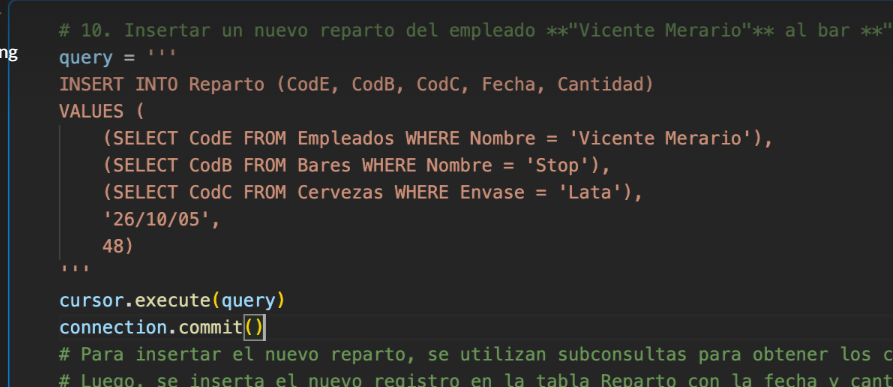

In [71]:
print (codigoE["CodE"].iloc[0])
print (codigoB["CodB"].iloc[0])
print (codigoC["CodC"].iloc[0])

2
001
3


In [ ]:
#No ejecutarlo otra vez. Da mal. Explicación abajo
query = '''
 INSERT INTO Reparto (CodE, CodB, CodC, Fecha, Cantidad)
 VALUES 
    (?, ?, ?, ?, ?);
'''

nuevo_reparto = [

    (codigoE["CodE"].iloc[0], codigoB["CodB"].iloc[0], codigoC["CodC"].iloc[0], "2005-10-26", 48)
]

crsr.executemany (query, nuevo_reparto)

In [64]:
#comprobación
query = ''' 
SELECT * FROM Reparto
       '''
crsr.execute(query).fetchall()

[(1, '001', '01', '2005-10-21', 240),
 (1, '001', '02', '2005-10-21', 48),
 (1, '002', '03', '2005-10-22', 60),
 (1, '004', '05', '2005-10-22', 4),
 (2, '002', '03', '2005-10-22', 48),
 (2, '002', '05', '2005-10-23', 2),
 (2, '004', '01', '2005-10-23', 480),
 (2, '004', '02', '2005-10-24', 72),
 (3, '003', '03', '2005-10-24', 48),
 (3, '003', '04', '2005-10-25', 20),
 (b'\x02\x00\x00\x00\x00\x00\x00\x00',
  '001',
  b'\x03\x00\x00\x00\x00\x00\x00\x00',
  '2005-10-26',
  48)]

In [72]:
#Inserta los valores como bytes. Después de buscar por qué parece que habría que convertirlo a entero antes. 
#Acordarse de preguntar por qué. Dejo lo de a
query = '''
 INSERT INTO Reparto (CodE, CodB, CodC, Fecha, Cantidad)
 VALUES 
    (?, ?, ?, ?, ?);
'''

nuevo_reparto = [

    (int(codigoE["CodE"].iloc[0]), codigoB["CodB"].iloc[0], int(codigoC["CodC"].iloc[0]), "2005-10-26", 48)
]

crsr.executemany (query, nuevo_reparto)

In [73]:
#comprobación
query = ''' 
SELECT * FROM Reparto
       '''
crsr.execute(query).fetchall()

[(1, '001', '01', '2005-10-21', 240),
 (1, '001', '02', '2005-10-21', 48),
 (1, '002', '03', '2005-10-22', 60),
 (1, '004', '05', '2005-10-22', 4),
 (2, '002', '03', '2005-10-22', 48),
 (2, '002', '05', '2005-10-23', 2),
 (2, '004', '01', '2005-10-23', 480),
 (2, '004', '02', '2005-10-24', 72),
 (3, '003', '03', '2005-10-24', 48),
 (3, '003', '04', '2005-10-25', 20),
 (2, '001', '3', '2005-10-26', 48)]